In [27]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,confusion_matrix,ConfusionMatrixDisplay
from  sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_blobs
import pandas as pd


# Question 1

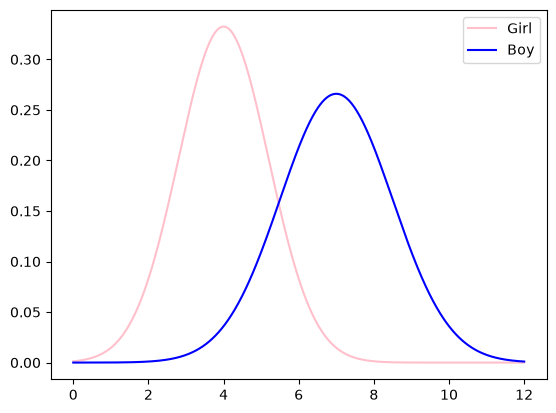

(3500, 1)
(3500,)
Accuracy score: 0.874


In [2]:
np.random.seed(42)
girl_dist = stats.norm(4.0, 1.2)
boy_dist = stats.norm(7.0, 1.5)

x = np.linspace(0, 12, 1000)

plt.plot(x, girl_dist.pdf(x), label="Girl", color="pink")
plt.plot(x, boy_dist.pdf(x), label="Boy", color="blue")
plt.legend()
plt.show()

np.random.seed(42)
n = 5000

X_g = girl_dist.rvs(int(n * 0.7)).reshape(-1, 1)
y_g = np.array([0] * (int(n * 0.7)))
X_b = boy_dist.rvs(int(n * 0.3)).reshape(-1, 1)
y_b = np.array([1] * (int(n * 0.3)))
X = np.vstack((X_g, X_b))
y = np.hstack((y_g, y_b))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
knn = KNeighborsClassifier(n_neighbors=17)
print(X_train.shape)
print(y_train.shape)
knn.fit(X_train, y_train)
print(f"Accuracy score: {knn.score(X_test, y_test)}")

# Quesiton 2

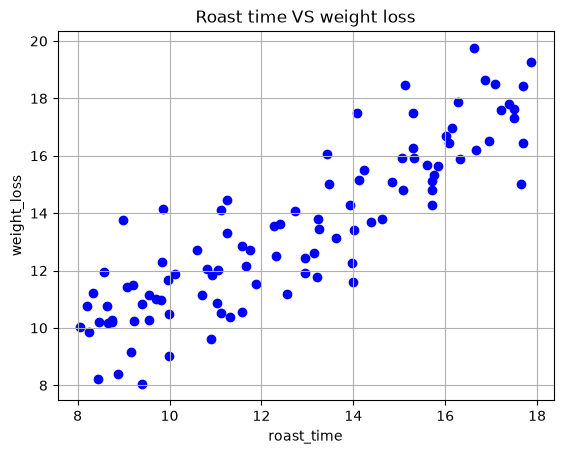

In [3]:
np.random.seed(42)
# n sample
n = 100
# roast time distribution
roast_time = np.random.uniform(8, 18, n)
# bias + weight * roast time + noise
weight_loss = 2.0 + 0.9 * roast_time + np.random.normal(0, 1.5, n)

# scatter plot
plt.scatter(roast_time, weight_loss, c="blue")
plt.title("Roast time VS weight loss")
plt.xlabel("roast_time")
plt.ylabel("weight_loss")
plt.grid()
plt.show()

R2 Score = 0.8072059636181392
MSE = 1.4708239058632542
Intercept = 2.69599320123519
Coeficient = [0.8397971]


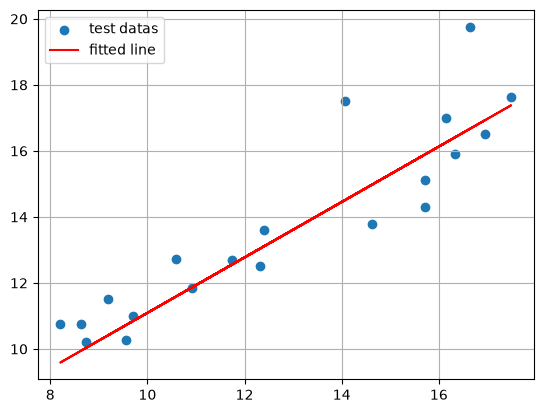

In [4]:
# fit model
Xtrain, Xtest, ytrain, ytest = train_test_split(
    roast_time.reshape(-1, 1), weight_loss, test_size=0.2, random_state=42
)

linear_reg = LinearRegression()
linear_reg.fit(Xtrain, ytrain)

ypred = linear_reg.predict(Xtest)
coef = linear_reg.coef_
intercept = linear_reg.intercept_

mse = mean_squared_error(ytest, ypred)
r2_s = r2_score(ytest, ypred)

print(f"R2 Score = {r2_s}\nMSE = {mse}\nIntercept = {intercept}\nCoeficient = {coef}")

plt.scatter(Xtest, ytest, label="test datas")
plt.plot(Xtest, ypred, c="red", label="fitted line")
plt.legend()
plt.grid()
plt.show()

# More noise

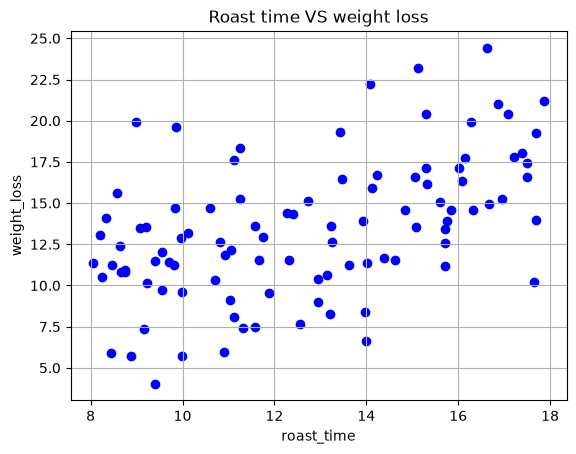

In [5]:
np.random.seed(42)
# n sample
n = 100
# roast time distribution
roast_time = np.random.uniform(8, 18, n)
# bias + weight * roast time + noise
weight_loss = 2.0 + 0.9 * roast_time + np.random.normal(0, 4, n)

# scatter plot
plt.scatter(roast_time, weight_loss, c="blue")
plt.title("Roast time VS weight loss")
plt.xlabel("roast_time")
plt.ylabel("weight_loss")
plt.grid()
plt.show()

R2 Score = 0.22139900300885773
MSE = 10.459192219472033
Intercept = 3.855981869960509
Coeficient = [0.73945893]


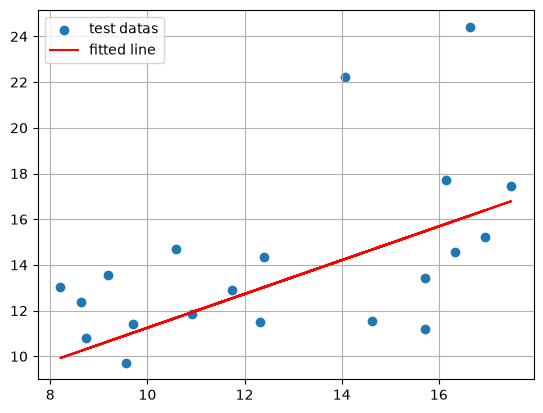

In [6]:
# fit model
Xtrain, Xtest, ytrain, ytest = train_test_split(
    roast_time.reshape(-1, 1), weight_loss, test_size=0.2, random_state=42
)

linear_reg = LinearRegression()
linear_reg.fit(Xtrain, ytrain)

ypred = linear_reg.predict(Xtest)
coef = linear_reg.coef_
intercept = linear_reg.intercept_

mse = mean_squared_error(ytest, ypred)
r2_s = r2_score(ytest, ypred)

print(f"R2 Score = {r2_s}\nMSE = {mse}\nIntercept = {intercept}\nCoeficient = {coef}")

plt.scatter(Xtest, ytest, label="test datas")
plt.plot(Xtest, ypred, c="red", label="fitted line")
plt.legend()
plt.grid()
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

# Question 3

coef:[6.93127329]
intercept:-8.50175800877608


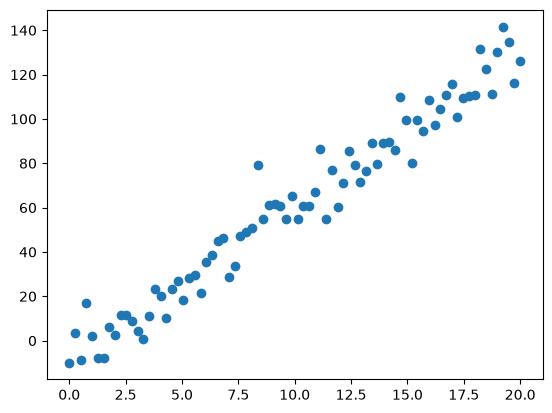

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x = np.linspace(0, 20, 80)
noise = np.random.normal(0, 8, 80)
y = 7 * x - 10 + noise
model = LinearRegression()
model.fit(x.reshape(-1, 1), y)
print(f"coef:{model.coef_}")
print(f"intercept:{model.intercept_}")
plt.scatter(x, y)
plt.show()

# Question 4

r2_score:0.11677944240246463


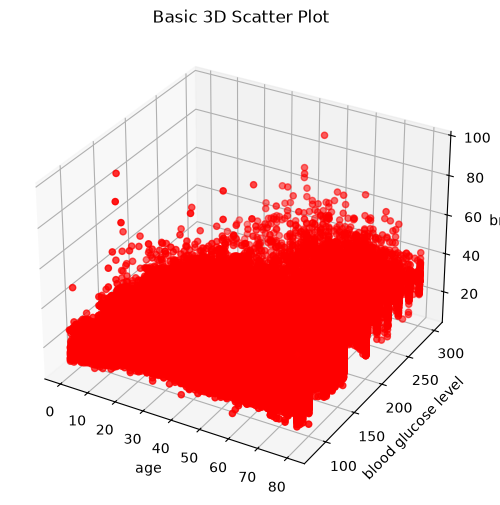

In [9]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_prediction_dataset1.csv")
small_df = df.loc[:, ["age", "blood_glucose_level", "bmi"]]
X = small_df.iloc[:, :-1]
y = small_df.iloc[:, -1]
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_scaled = (X - X_min) / (X_max - X_min)
scaler = StandardScaler()
x_standard = scaler.fit_transform(X)
model = LinearRegression()
model.fit(x_standard, y)
y_pred = model.predict(x_standard)
r2 = r2_score(y, y_pred)
print(f"r2_score:{r2}")


x = small_df["age"]
y = small_df["blood_glucose_level"]
z = small_df["bmi"]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter3D(x, y, z, color="red", marker="o")

ax.set_xlabel("age")
ax.set_ylabel("blood glucose level")
ax.set_zlabel("bmi")
ax.set_title("Basic 3D Scatter Plot")

plt.show()

# Question 5

In [10]:
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
#Data set
df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_prediction_dataset1.csv")
# X , y
X = df.loc[:, ["HbA1c_level", "bmi", "blood_glucose_level"]]
y = df.iloc[:, -1]
# split sets
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
#scaler tool
scaler = StandardScaler()
#transform datas 
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
# fit model
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
y_predict = model.predict(x_test_scaled)

# accuracy_train = model.score(x_train_scaled, y_train)
# print(f"accuracy train:{accuracy_train}")
#model evaluate
accuracy_test = model.score(x_test_scaled, y_test)
print(f"accuracy test:{accuracy_test}")
y_test_1 = y_test

accuracy test:0.9598


In [11]:

import pandas as pd
from sklearn.metrics import r2_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_dataset2.csv")

X = df.loc[:, ["Age", "GenHlth", "BMI", "HighBP"]]
y = df.iloc[:, -1]
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
model = LogisticRegression()
model.fit(x_train_scaled, y_train)
accuracy_test = model.score(x_test_scaled, y_test)

print(f"accuracy test:{accuracy_test}")
classification_report = classification_report(y_test, model.predict(x_test_scaled))

print(classification_report)


accuracy test:0.3629375591296121
              precision    recall  f1-score   support

         1.0       0.20      0.07      0.10      2943
         2.0       0.16      0.12      0.14      3535
         3.0       0.19      0.00      0.01      4798
         4.0       0.00      0.00      0.00      6041
         5.0       0.17      0.02      0.04      7765
         6.0       0.16      0.04      0.07     10941
         7.0       0.17      0.00      0.00     12966
         8.0       0.38      0.97      0.55     27115

    accuracy                           0.36     76104
   macro avg       0.18      0.15      0.11     76104
weighted avg       0.24      0.36      0.22     76104



e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
y_predict.shape

(30000,)

In [13]:

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

conf = confusion_matrix(y_test_1, y_predict)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_predict, display_labels=model.classes_, cmap=plt.cm.Blues
)

plt.title("Confusion Matrix (from_predictions)")
plt.show()

tp = conf[1, 1]
fp = conf[0, 1]
fn = conf[1, 0]
tn = conf[0, 0]

precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)
classification_record = classification_report(y_test, y_predict)
print(
    f"precision:{precision}, recall:{recall}, f1_score:{f1_score} classification_record {classification_record}"
)

ValueError: Found input variables with inconsistent numbers of samples: [76104, 30000, 76104]

# Question 7

In [ ]:
import numpy as np

p1 = 0.1
p2 = 0.8


def cross_entropy_loss_function(Y, P):
    epsilon = 1e-10
    loss = -np.mean(np.sum(Y * np.log(P + epsilon)))
    return loss


print(cross_entropy_loss_function(y_predict, p1))
print(cross_entropy_loss_function(y_predict, p2))

3808.4757421581517
369.07943366695287


# Question 8

In [ ]:
# read dataset diabetes
df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_prediction_dataset1.csv")
display(df.head(10))
display(df.describe())
print(df.info())

# split data
X = df.loc[:, ["HbA1c_level", "bmi", "blood_glucose_level"]]
y = df.iloc[:, -1]

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True,stratify=y)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB
None


In [ ]:
# models
gini_tree = DecisionTreeClassifier(criterion='gini',max_depth=5)
entropy_tree = DecisionTreeClassifier(criterion='entropy',max_depth=5)

# fit models
gini_tree.fit(Xtrain,ytrain)
entropy_tree.fit(Xtrain,ytrain)


#evaluate
print(f"{"Gini criterion  ":<20}: {gini_tree.score(Xtest,ytest)} ")
print(f"{"Entropy criterion  ":<20}: {entropy_tree.score(Xtest,ytest)}")



Gini criterion      : 0.9724 
Entropy criterion   : 0.9724


# None Linear data

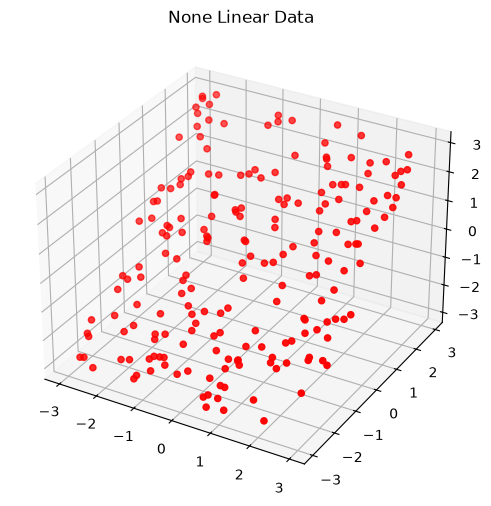

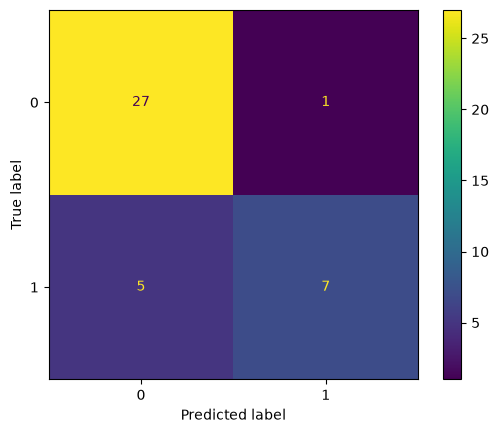

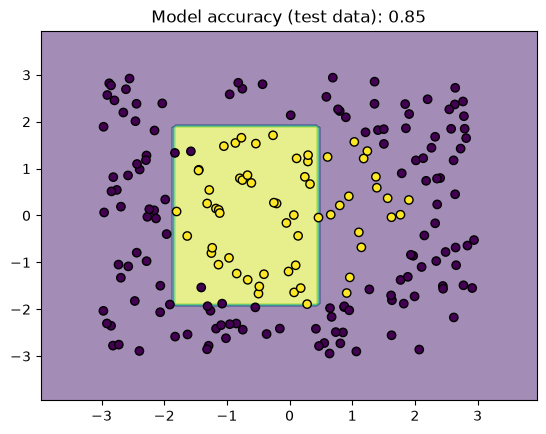

In [41]:
np.random.seed(42)
n = 200
X = np.random.uniform(-3,3,(n,2))
y = X[:,0]**2 + X[:,1]**2
y_cat = np.where(y < 4,1,0)

x = X[:,0]
y = X[:,1]
z = y

fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter3D(x, y, z, color="red", marker="o")

ax.set_title("None Linear Data")

plt.show()
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y_cat , test_size=0.2,random_state=42,shuffle=True, stratify=y_cat)
tree = DecisionTreeClassifier(max_depth=4)
tree.fit(Xtrain,ytrain)
ypred = tree.predict(Xtest)

cm = confusion_matrix(ytest, ypred, labels=tree.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=tree.classes_)
disp.plot()
plt.show()


disp = DecisionBoundaryDisplay.from_estimator(
    tree, 
    X, 
    response_method="predict",
    alpha=0.5, 
)

plt.scatter(X[:, 0], X[:, 1], c=y_cat, edgecolor="k")
plt.title(f"Model accuracy (test data): {tree.score(Xtest,ytest)}")
plt.show()

# Question 9

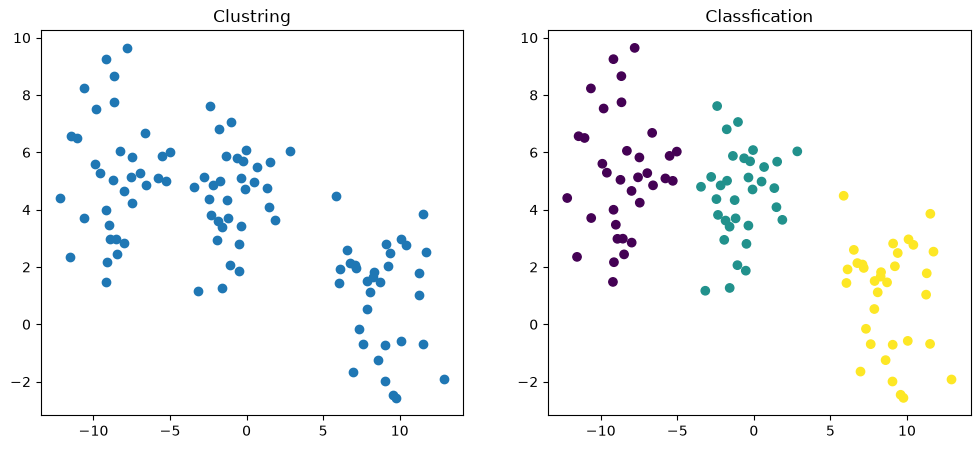

In [ ]:
# make dataset
X,y = make_blobs(cluster_std=1.8,random_state=7)
# classification plot and clustring plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1])
plt.title('Clustring')

plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],c=y)
plt.title("Classfication")

plt.show()

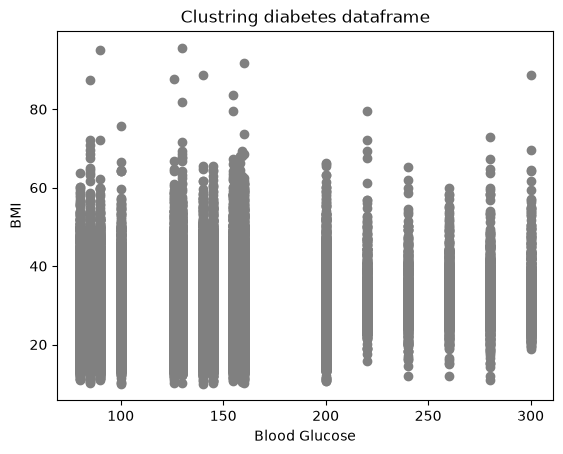

,blood_glucose_level,bmi
0,140,25.19
1,80,27.32
2,158,27.32
3,155,23.45
4,155,20.14


,bmi
blood_glucose_level,0.091261
bmi,1.000000


In [39]:
df = pd.read_csv(r"E:\Maktab-145\Datasets\diabetes_prediction_dataset1.csv")

df_small = df.loc[:,["blood_glucose_level","bmi"]]
df_small.head()
plt.scatter(df_small["blood_glucose_level"],df_small["bmi"],c='gray')
plt.title("Clustring diabetes dataframe")
plt.xlabel("Blood Glucose")
plt.ylabel("BMI")
plt.show()
display(df_small.head())
df_small.corr()['bmi'].to_frame()